# SHMS 6维输入 → 3维输出（不训练 Delta）Notebook

本 notebook 使用 `mc-single-arm` 生成的 ROOT 文件（树名 `h10`）进行神经网络训练。

## 列映射（基于你当前工程约定）

- 输入 6 维：`[psxfp, psyfp, psxpfp, psypfp, psxtari, p0]`
  - 对应内部键：`[x_fp, y_fp, xp_fp, yp_fp, x_tar, p0]`
- 输出 3 维（去掉 delta）：`[psxptari, psyptari, psztari]`
  - 对应内部键：`[xptar, yptar, ytar]`

 > 说明：这里默认使用 *thrown truth* (`*i`) 作为监督标签。

In [50]:
# 如果你当前环境缺包，取消注释安装
# !pip install uproot awkward numpy pandas scikit-learn torch matplotlib

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import uproot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

# 让 notebook 能直接导入 training 包（兼容多种启动目录）
def find_repo_root_for_training(start: Path) -> Path:
    candidates = [start, *start.parents]
    for base in candidates:
        # 情况1：当前目录本身就是 SHMS_Calibration_NN 仓库根
        if (base / 'training').is_dir():
            return base
        # 情况2：当前目录是更上层工作区（如 AI_ML R-SIDIS）
        if (base / 'SHMS_Calibration_NN' / 'training').is_dir():
            return base / 'SHMS_Calibration_NN'
    raise RuntimeError(
        f"无法定位 training 包。当前工作目录: {start}\n"
        "请从仓库根目录 SHMS_Calibration_NN 或其上层工作区启动 notebook。"
    )

repo_root = find_repo_root_for_training(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print('Resolved repo_root:', repo_root)
from training.models.residual_mlp import ResidualMLP

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Resolved repo_root: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN
Device: cuda


In [47]:
# ====== 数据路径与训练超参数 ======
ROOT_FILE = Path(r"C:/Users/Lanto/Desktop/AI_ML R-SIDIS/mc-single-arm/worksim/shms_nn_train_3gev15deg.root")
TREE_NAME = 'h10'

# 若文件是其它动量设置，请改为对应 p0（GeV/c）
P0_GEV = 1.4

# 训练超参数
BATCH_SIZE = 2048
EPOCHS = 120
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_FRACTION = 0.2
EARLY_STOPPING_PATIENCE = 20
EARLY_STOPPING_MIN_DELTA = 1e-4
GRAD_CLIP_MAX_NORM = 1.0
INPUT_NOISE_STD = 0.01

# 学习率调度器（验证集loss平台期自动降学习率）
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 8
MIN_LR = 1e-6

# 模型结构超参数（适当降容量，缓解过拟合）
HIDDEN_DIM = 128
N_RESIDUAL_BLOCKS = 2
BRANCH_DIM = 32

# 多目标损失权重（进一步提升 yptar/ytar 的训练关注度）
# 顺序必须与 TARGET_COLS 一致: [psxptari, psyptari, psztari]
TARGET_LOSS_WEIGHTS = [1.0, 2.5, 3.0]

# 特征工程（重点增强 y 平面相关可学习性）
USE_FEATURE_ENGINEERING = True

# 输入/输出列（6 -> 3，关闭delta训练）
INPUT_COLS = ['psxfp', 'psyfp', 'psxpfp', 'psypfp', 'psxtari']  # + p0 常量列
TARGET_COLS = ['psxptari', 'psyptari', 'psztari']

assert ROOT_FILE.exists(), f'ROOT file not found: {ROOT_FILE}'
print('ROOT file:', ROOT_FILE)
print('Input cols :', INPUT_COLS + ['p0'])
print('Target cols:', TARGET_COLS)
print('TARGET_LOSS_WEIGHTS:', TARGET_LOSS_WEIGHTS)
print('USE_FEATURE_ENGINEERING:', USE_FEATURE_ENGINEERING)

ROOT file: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\worksim\shms_nn_train_3gev15deg.root
Input cols : ['psxfp', 'psyfp', 'psxpfp', 'psypfp', 'psxtari', 'p0']
Target cols: ['psxptari', 'psyptari', 'psztari']
TARGET_LOSS_WEIGHTS: [1.0, 2.5, 3.0]
USE_FEATURE_ENGINEERING: True


In [48]:
# ====== 读 ROOT 并构建输入特征 / 3维输出 ======
with uproot.open(ROOT_FILE) as f:
    tree = f[TREE_NAME]
    available = set(tree.keys())
    needed = INPUT_COLS + TARGET_COLS
    missing = [c for c in needed if c not in available]
    if missing:
        raise KeyError(f'Missing branches: {missing}')

    df = tree.arrays(needed, library='pd')

# 可选：过滤异常值/失败事件（如果存在 stop_id 且你想只保留成功事件）
# if 'stop_id' in tree.keys():
#     stop_id = tree['stop_id'].array(library='np')
#     df = df[stop_id == 0].reset_index(drop=True)

# 基础6维特征（与现有 pipeline 保持一致）
x_fp = df['psxfp'].to_numpy(dtype=np.float32)
y_fp = df['psyfp'].to_numpy(dtype=np.float32)
xp_fp = df['psxpfp'].to_numpy(dtype=np.float32)
yp_fp = df['psypfp'].to_numpy(dtype=np.float32)
x_tar = df['psxtari'].to_numpy(dtype=np.float32)
p0 = np.full(len(df), P0_GEV, dtype=np.float32)

feature_list = [x_fp, y_fp, xp_fp, yp_fp, x_tar, p0]
feature_names = ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0']

if USE_FEATURE_ENGINEERING:
    # 针对 yptar / ytar 增强的非线性与交叉项
    fe_terms = [
        yp_fp * yp_fp,
        y_fp * yp_fp,
        x_tar * yp_fp,
        x_tar * y_fp,
        x_fp * yp_fp,
        np.sin(yp_fp),
        np.cos(yp_fp),
        y_fp * y_fp,
    ]
    fe_names = [
        'yp_fp_sq', 'y_fp_mul_yp_fp', 'x_tar_mul_yp_fp', 'x_tar_mul_y_fp',
        'x_fp_mul_yp_fp', 'sin_yp_fp', 'cos_yp_fp', 'y_fp_sq'
    ]
    feature_list.extend([arr.astype(np.float32) for arr in fe_terms])
    feature_names.extend(fe_names)

X = np.stack(feature_list, axis=1).astype(np.float32)
Y = df[TARGET_COLS].to_numpy(dtype=np.float32)

print('Samples:', len(df))
print('X shape:', X.shape)
print('Y shape:', Y.shape)
print('Feature names:', feature_names)
df.head()

Samples: 100000
X shape: (100000, 14)
Y shape: (100000, 3)
Feature names: ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0', 'yp_fp_sq', 'y_fp_mul_yp_fp', 'x_tar_mul_yp_fp', 'x_tar_mul_y_fp', 'x_fp_mul_yp_fp', 'sin_yp_fp', 'cos_yp_fp', 'y_fp_sq']


,psxfp,psyfp,psxpfp,psypfp,psxtari,psxptari,psyptari,psztari
0,0.0,0.0,0.0,0.0,0.002252,0.003107,-0.050313,-0.993690
1,0.0,0.0,0.0,0.0,0.040946,0.027044,-0.029069,-1.005781
2,0.0,0.0,0.0,0.0,0.035753,0.032978,0.046197,-1.007046
3,0.0,0.0,0.0,0.0,0.020304,0.016539,0.042958,-1.003679
4,0.0,0.0,0.0,0.0,0.049332,0.045132,0.002561,-1.007427


In [51]:
# ====== 划分数据 + 标准化 ======
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=VAL_FRACTION, random_state=SEED
)

# 输入使用 StandardScaler；输出使用 RobustScaler（对长尾/异常更稳）
scaler_X = StandardScaler().fit(X_train)
scaler_Y = RobustScaler(quantile_range=(5.0, 95.0)).fit(Y_train)

X_train_s = scaler_X.transform(X_train).astype(np.float32)
X_val_s = scaler_X.transform(X_val).astype(np.float32)
Y_train_s = scaler_Y.transform(Y_train).astype(np.float32)
Y_val_s = scaler_Y.transform(Y_val).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_train_s), torch.from_numpy(Y_train_s))
val_ds = TensorDataset(torch.from_numpy(X_val_s), torch.from_numpy(Y_val_s))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print('Train size:', len(train_ds), '| Val size:', len(val_ds))

Train size: 80000 | Val size: 20000


In [52]:
# ====== 复用 training 的 ResidualMLP，并训练 3 输出（no-delta, anti-overfit + y-boost） ======
import torch.nn.functional as F

class ResidualMLP3HeadAdapter(nn.Module):
    """
    直接复用 training.models.residual_mlp.ResidualMLP 作为 backbone+heads，
    前向时仅输出 [xptar, yptar, ytar] 三列。
    """
    def __init__(self, base_model: ResidualMLP):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        out = self.base(x)  # dict: delta/xptar/yptar/ytar
        return torch.cat([out['xptar'], out['yptar'], out['ytar']], dim=1)


base_model = ResidualMLP(
    input_dim=X_train_s.shape[1],
    hidden_dim=HIDDEN_DIM,
    n_residual_blocks=N_RESIDUAL_BLOCKS,
    branch_dim=BRANCH_DIM,
)
model = ResidualMLP3HeadAdapter(base_model).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE, min_lr=MIN_LR
)

target_loss_weights = torch.tensor(TARGET_LOSS_WEIGHTS, dtype=torch.float32, device=device)

def weighted_huber_loss(pred, target, weights, beta=1.0):
    # pred/target: (batch, 3)
    per_elem = F.smooth_l1_loss(pred, target, reduction='none', beta=beta)
    per_dim = per_elem.mean(dim=0)
    return (per_dim * weights).sum() / weights.sum()

train_losses, val_losses = [], []
best_val = float('inf')
best_state = None
best_epoch = 0
epochs_without_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    n_tr = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # 输入噪声正则化（仅训练阶段）
        if INPUT_NOISE_STD > 0.0:
            xb = xb + torch.randn_like(xb) * INPUT_NOISE_STD

        optimizer.zero_grad()
        pred = model(xb)
        loss = weighted_huber_loss(pred, yb, target_loss_weights, beta=1.0)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_MAX_NORM)
        optimizer.step()

        bs = xb.size(0)
        tr_loss += loss.item() * bs
        n_tr += bs

    model.eval()
    va_loss = 0.0
    n_va = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = weighted_huber_loss(pred, yb, target_loss_weights, beta=1.0)
            bs = xb.size(0)
            va_loss += loss.item() * bs
            n_va += bs

    tr_loss /= max(n_tr, 1)
    va_loss /= max(n_va, 1)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    scheduler.step(va_loss)

    improved = (best_val - va_loss) > EARLY_STOPPING_MIN_DELTA
    if improved:
        best_val = va_loss
        best_epoch = epoch
        epochs_without_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improve += 1

    if epoch == 1 or epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:03d} | lr={current_lr:.2e} | train={tr_loss:.6f} | val={va_loss:.6f}')

    if epochs_without_improve >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch}, best epoch = {best_epoch}, best val = {best_val:.6f}')
        break

print('Best epoch:', best_epoch)
print('Best val loss:', best_val)

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 001 | lr=1.00e-03 | train=0.045674 | val=0.043954
Epoch 010 | lr=1.00e-03 | train=0.043645 | val=0.043741
Epoch 020 | lr=1.00e-03 | train=0.043526 | val=0.043581
Epoch 030 | lr=1.00e-03 | train=0.043390 | val=0.043483
Epoch 040 | lr=1.00e-03 | train=0.043353 | val=0.043505
Early stopping at epoch 42, best epoch = 22, best val = 0.043548
Best epoch: 22
Best val loss: 0.04354808413982391


 xptar | RMSE=0.009031 | MAE=0.007131 | R2=0.902565
 yptar | RMSE=0.031083 | MAE=0.025145 | R2=0.038631
  ytar | RMSE=0.005773 | MAE=0.005003 | R2=0.000108


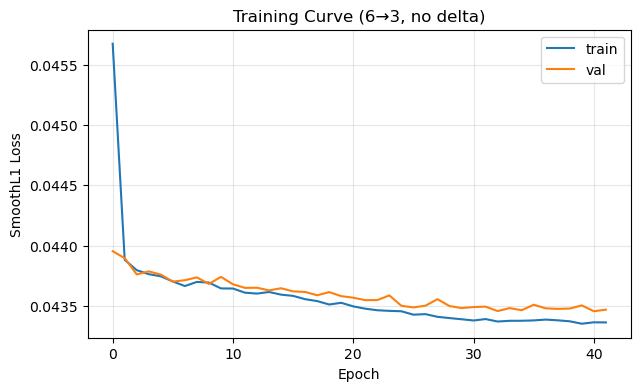

In [53]:
# ====== 评估（反归一化后） ======
model.eval()
with torch.no_grad():
    y_pred_val_s = model(torch.from_numpy(X_val_s).to(device)).cpu().numpy()

y_pred_val = scaler_Y.inverse_transform(y_pred_val_s)
y_true_val = Y_val

target_names = ['xptar', 'yptar', 'ytar']
for i, name in enumerate(target_names):
    mse = mean_squared_error(y_true_val[:, i], y_pred_val[:, i])
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true_val[:, i], y_pred_val[:, i])
    r2 = r2_score(y_true_val[:, i], y_pred_val[:, i])
    print(f'{name:>6s} | RMSE={rmse:.6f} | MAE={mae:.6f} | R2={r2:.6f}')

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.title('Training Curve (6→3, no delta)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
# ====== 保存模型与scaler（供后续推理/微调） ======
out_dir = Path('../checkpoints/notebook_6to3_no_delta')
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / 'mlp_6to3_no_delta_best.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': int(X_train_s.shape[1]),
    'input_cols': feature_names,
    'target_cols': TARGET_COLS,
    'target_loss_weights': TARGET_LOSS_WEIGHTS,
    'use_feature_engineering': USE_FEATURE_ENGINEERING,
    'p0_gev': P0_GEV,
}, model_path)

scaler_bundle = {
    'input_features': feature_names,
    'target_features': ['xptar', 'yptar', 'ytar'],
    'X_center': scaler_X.mean_.tolist(),
    'X_scale': scaler_X.scale_.tolist(),
    'Y_center': scaler_Y.center_.tolist(),
    'Y_scale': scaler_Y.scale_.tolist(),
    'Y_scaler_type': 'RobustScaler(quantile_range=(5,95))',
}
with open(out_dir / 'scaler_bundle_notebook_6to3_no_delta.json', 'w', encoding='utf-8') as f:
    json.dump(scaler_bundle, f, indent=2, ensure_ascii=False)

print('Saved model :', model_path.resolve())
print('Saved scaler:', (out_dir / 'scaler_bundle_notebook_6to3_no_delta.json').resolve())

Saved model : C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\training\checkpoints\notebook_6to3_no_delta\mlp_6to3_no_delta_best.pth
Saved scaler: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\training\checkpoints\notebook_6to3_no_delta\scaler_bundle_notebook_6to3_no_delta.json


In [54]:
# ====== 快速诊断：过拟合程度与基线对比 ======
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

best_epoch = int(np.argmin(val_losses))
final_gap = float(val_losses[-1] - train_losses[-1])
best_gap = float(val_losses[best_epoch] - train_losses[best_epoch])

print(f"Best epoch: {best_epoch + 1}")
print(f"Train loss @best: {train_losses[best_epoch]:.6f}")
print(f"Val   loss @best: {val_losses[best_epoch]:.6f}")
print(f"Gap   loss @best: {best_gap:.6f}")
print(f"Train loss @last: {train_losses[-1]:.6f}")
print(f"Val   loss @last: {val_losses[-1]:.6f}")
print(f"Gap   loss @last: {final_gap:.6f}")

# 与“预测均值”基线对比（在原始物理量尺度）
y_pred_mean = np.tile(Y_train.mean(axis=0, keepdims=True), (len(Y_val), 1))
for i, name in enumerate(['xptar', 'yptar', 'ytar']):
    rmse_model = np.sqrt(mean_squared_error(Y_val[:, i], y_pred_val[:, i]))
    rmse_mean = np.sqrt(mean_squared_error(Y_val[:, i], y_pred_mean[:, i]))
    r2_model = r2_score(Y_val[:, i], y_pred_val[:, i])
    print(f"{name:>6s} | RMSE(model)={rmse_model:.6f} | RMSE(mean)={rmse_mean:.6f} | R2(model)={r2_model:.6f}")

Best epoch: 41
Train loss @best: 0.043364
Val   loss @best: 0.043456
Gap   loss @best: 0.000092
Train loss @last: 0.043363
Val   loss @last: 0.043469
Gap   loss @last: 0.000106
 xptar | RMSE(model)=0.009031 | RMSE(mean)=0.028933 | R2(model)=0.902565
 yptar | RMSE(model)=0.031083 | RMSE(mean)=0.031702 | R2(model)=0.038631
  ytar | RMSE(model)=0.005773 | RMSE(mean)=0.005773 | R2(model)=0.000108
